In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [16]:
def plot_confounding_level_vs_pvalue(source_index ):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    df_long = pd.concat([pd.DataFrame({"p-value": p_values1.iloc[:,source_index+1].values, "confounding": cn1}),
                            pd.DataFrame({"p-value": p_values3.iloc[:,source_index+1].values, "confounding": cn3}),
                            pd.DataFrame({"p-value": p_values6.iloc[:,source_index+1].values, "confounding": cn6})])
    sns.scatterplot(data=df_long, x="confounding", y="p-value", ax=ax)
# moving average
    df_long = df_long.sort_values("confounding").reset_index(drop=True)
    df_long["p-value"] = df_long["p-value"].rolling(window=30).mean()
    sns.lineplot(data=df_long, x="confounding", y="p-value", ax=ax)
    
    ax.set_title(f"Source {source_index}")

    plt.show()

## Increase in confounding simulation

In [17]:
# iv p value true source
p_values1 = pd.read_csv(f"../data_generation/different_confounding_levels/true_source_conf_{1}.csv", index_col=0)
p_values3 = pd.read_csv(f"../data_generation/different_confounding_levels/true_source_conf_{3}.csv", index_col=0)
p_values6 = pd.read_csv(f"../data_generation/different_confounding_levels/true_source_conf_{6}.csv", index_col=0)


In [18]:
# calculate level of confounding
cn1 = []
cn3 = []
cn6 = []

for i in range(100):
    mm1 = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_1_{i}.csv", index_col=None)
    mm3 = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_3_{i}.csv", index_col=None)
    mm6 = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_6_{i}.csv", index_col=None)
    cn1.append(level_of_confounding(mm1))
    cn3.append(level_of_confounding(mm3))
    cn6.append(level_of_confounding(mm6))


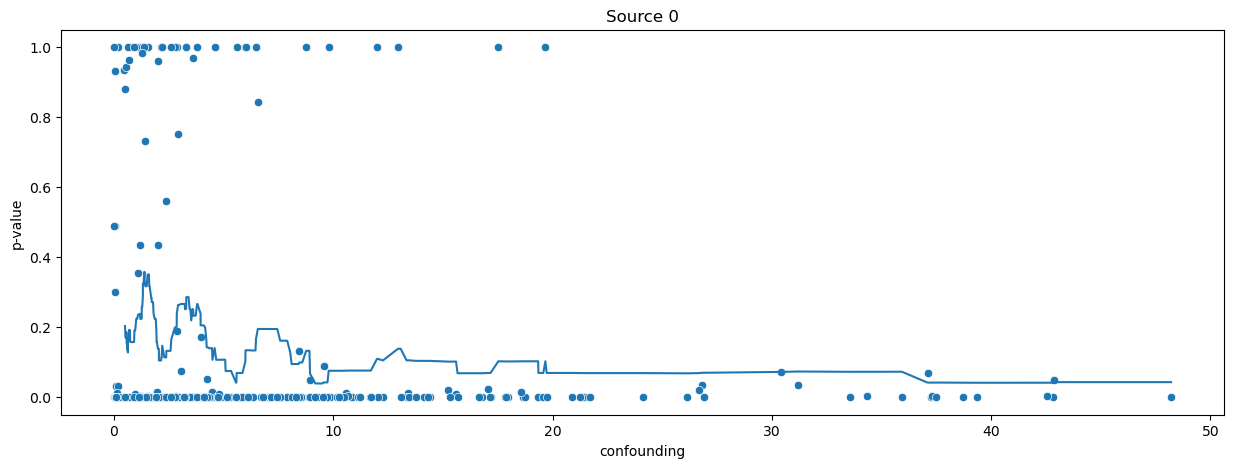

In [19]:
plot_confounding_level_vs_pvalue(0)

# Bounded confounding

In [28]:
def plot_confounding_level_vs_pvalue(source_index ):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    df_long = pd.DataFrame({"p-value": p_values1.iloc[:,source_index+1].values, "confounding": cn1})
    sns.scatterplot(data=df_long, x="confounding", y="p-value", ax=ax)
# moving average
    df_long = df_long.sort_values("confounding").reset_index(drop=True)
    df_long["p-value"] = df_long["p-value"].rolling(window=20).mean()

    sns.lineplot(data=df_long, x="confounding", y="p-value", ax=ax)
    
    ax.set_title(f"Source {source_index}")

    plt.show()

In [29]:
p_values = pd.read_csv(f"../data_generation/bounded_treatment_effect/CausalVarEM.csv", index_col=0)
cn = []
for i in range(100):
    mm = pd.read_csv(f"../data_generation/bounded_treatment_effect/data/true_mixing_init_flipp_{i}.csv", index_col=None)
    cn.append(level_of_confounding(mm))

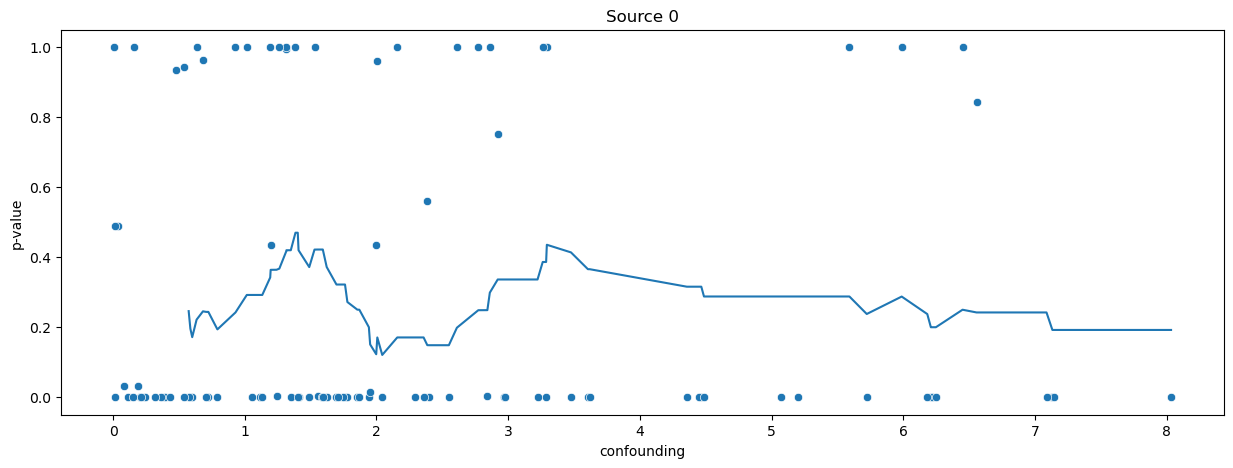

In [30]:
plot_confounding_level_vs_pvalue(0)
